# Lotka Volterra (1 parameter1) test case  

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [2]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [3]:
solver_HF = System1()
solver_LF = System1()

mu_values = np.linspace(1, 5, 10)
params = [(mu,) for mu in mu_values]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=8.0, params=np.array(params), h=0.02, fidelity='HF')
solver_HF.save_dataset('dataset_HF.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=8.0, params=np.array(params), h=0.05, fidelity='LF')
solver_LF.save_dataset('dataset_LF.h5')


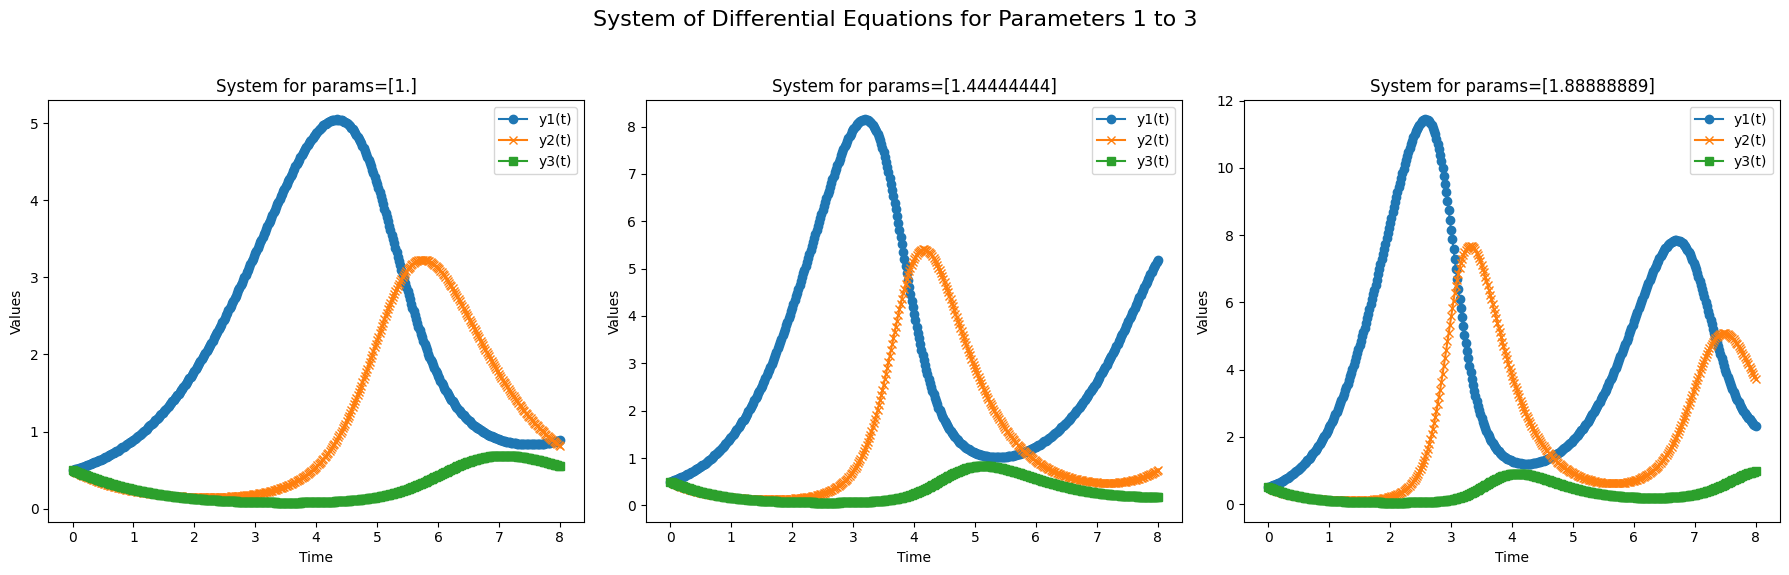

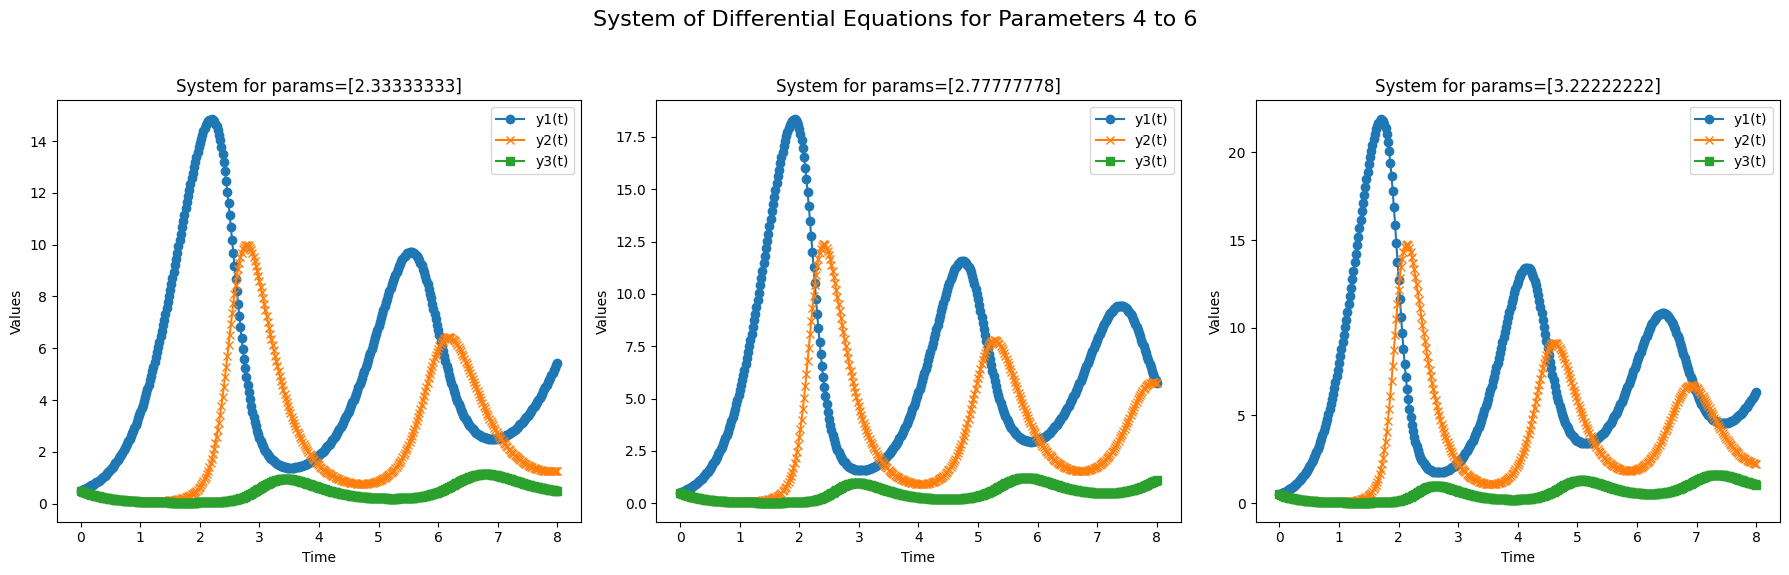

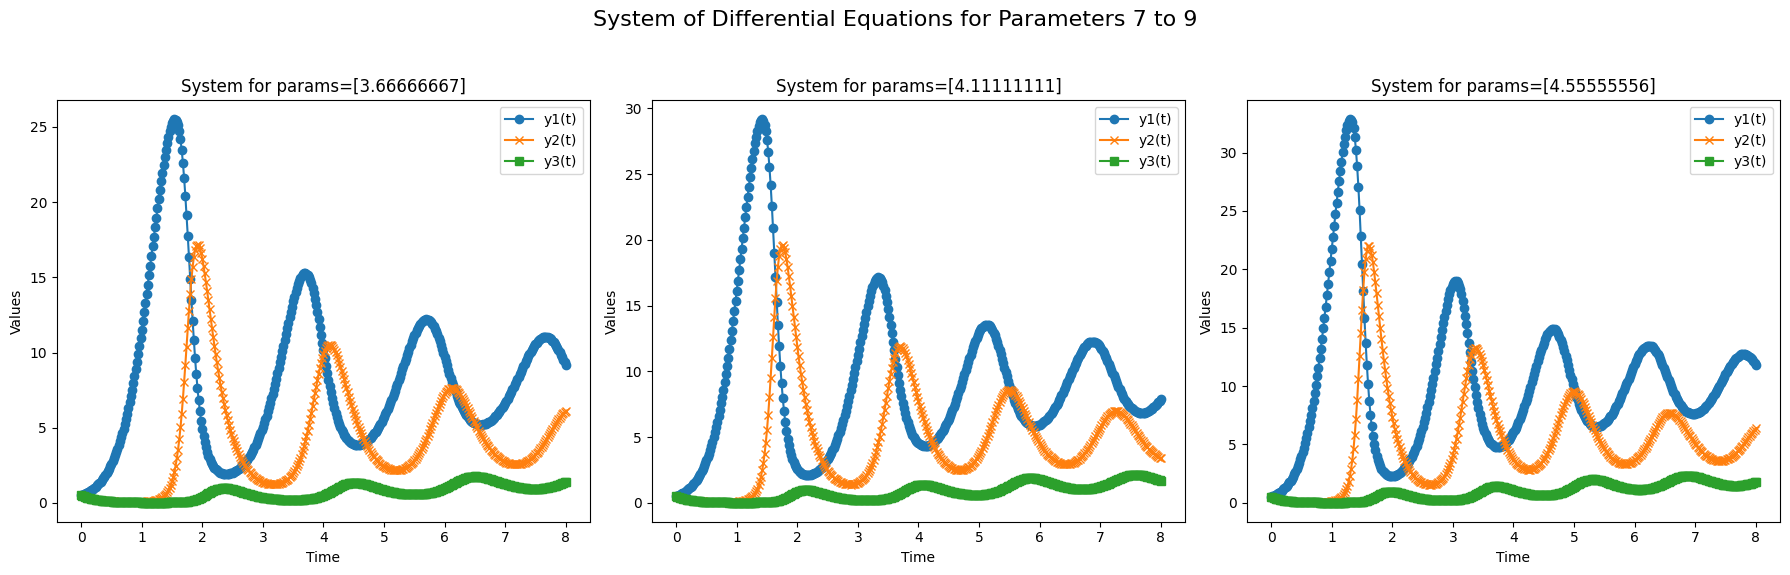

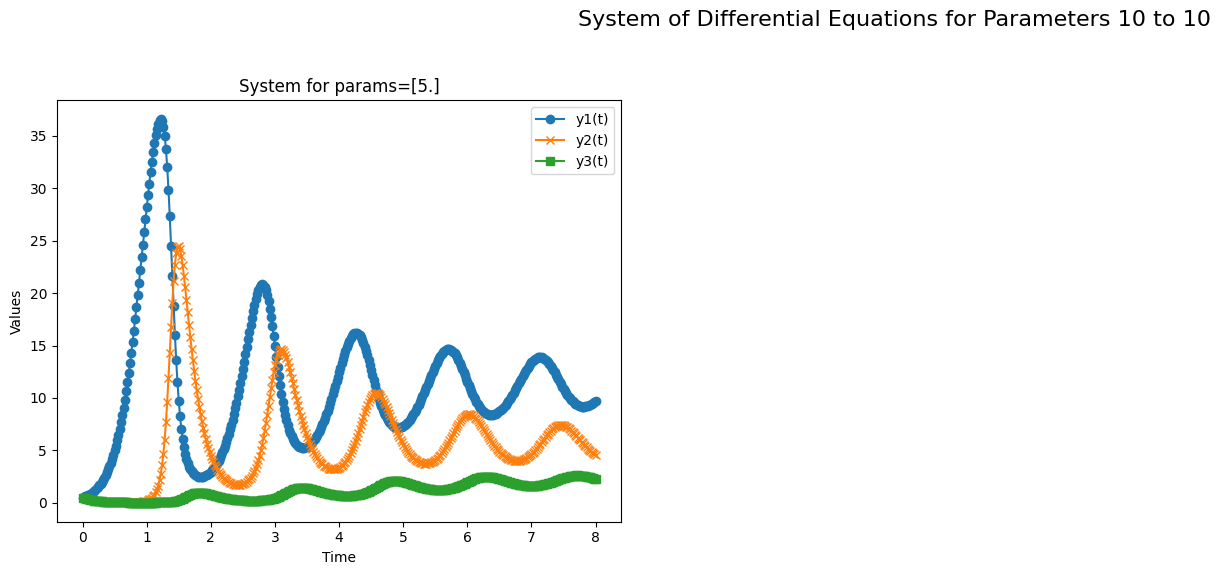

In [4]:
solver_HF.plot_results()

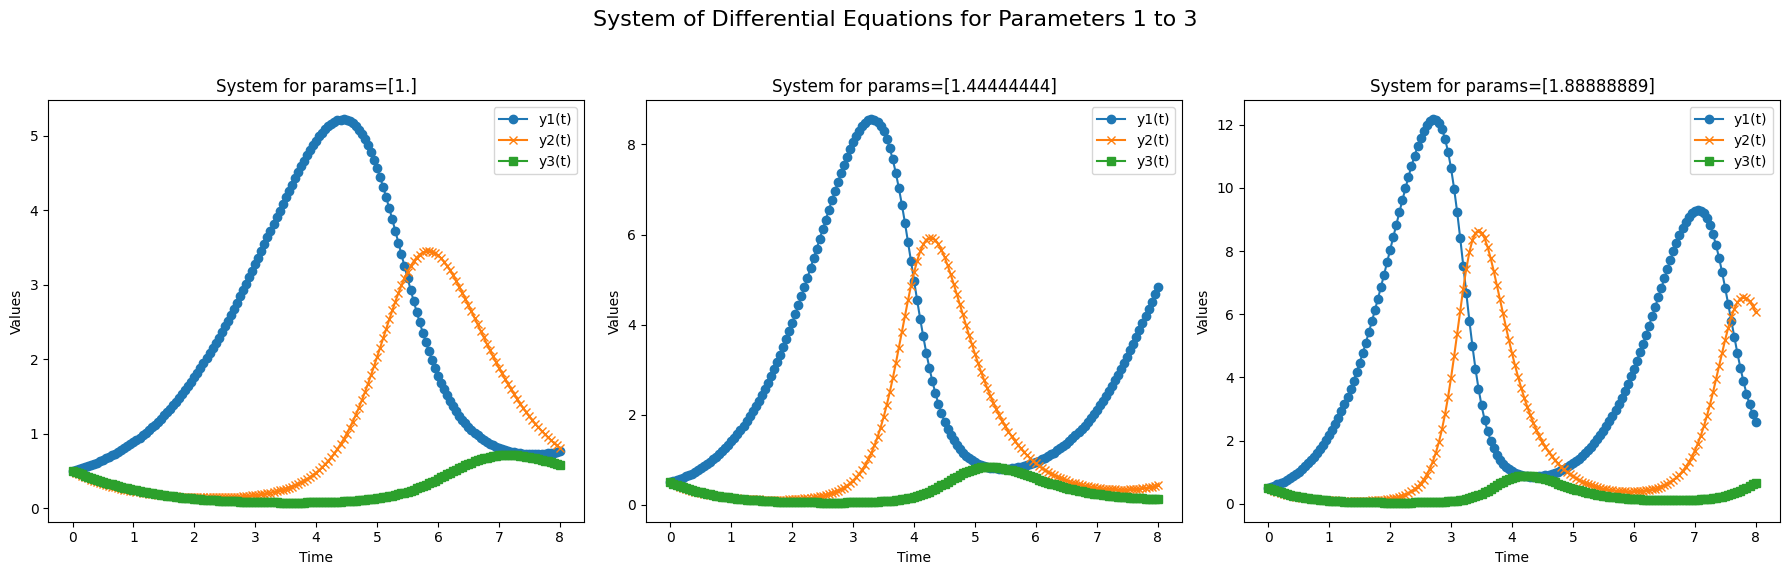

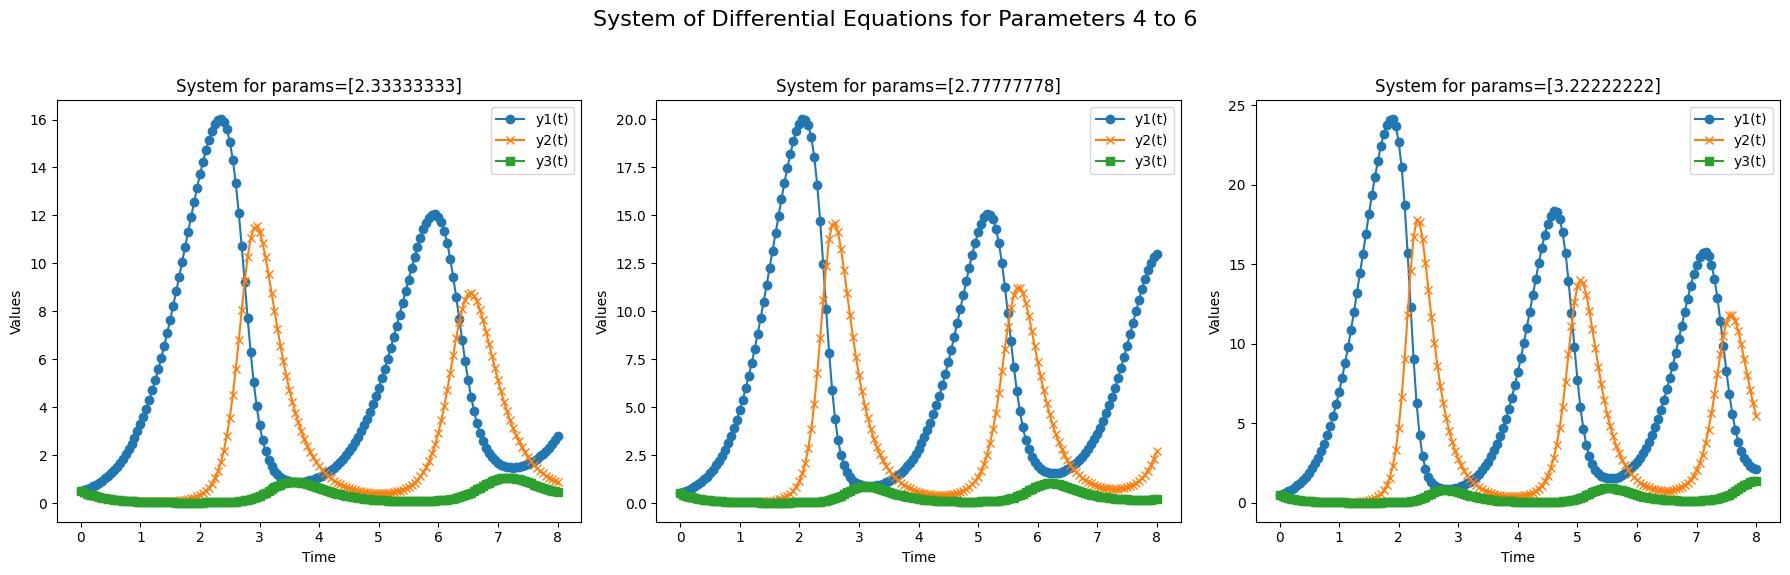

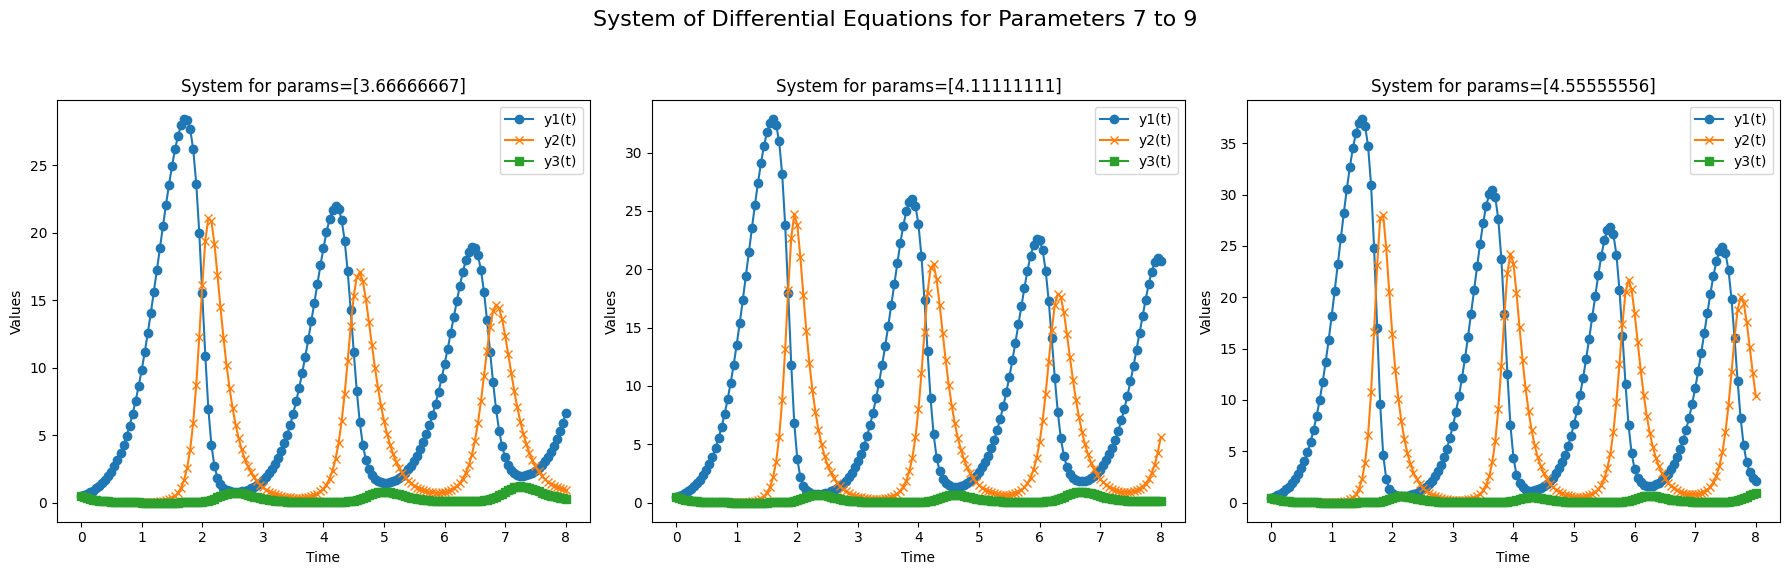

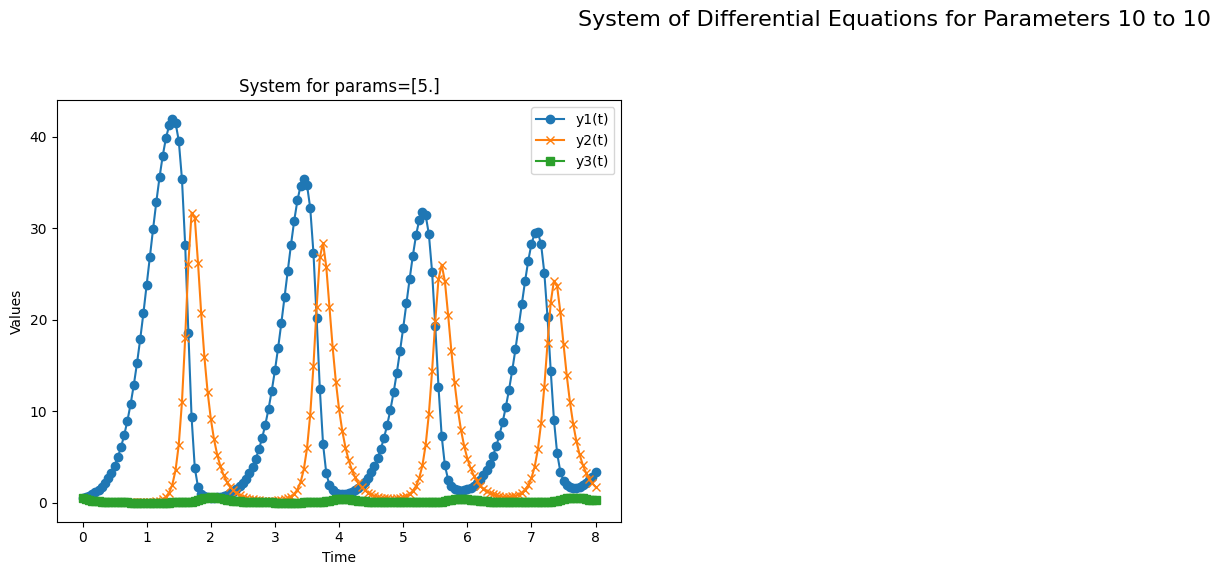

In [5]:
solver_LF.plot_results()

In [6]:

x_HF=np.array(np.meshgrid(mu_HF,t_HF)).T.reshape(-1, 2)[:,[1,0]]
x_LF=np.array(np.meshgrid(mu_LF,t_LF)).T.reshape(-1, 2)[:,[1,0]]


In [7]:
y_HF=np.array(y_HF).reshape(-1, 3)
y_LF=np.array(y_LF).reshape(-1, 3)

In [8]:
n_LF=1000
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_HF=2000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]

In [9]:
N=[400,1000]
n=[200,250]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:], y_HF[indices_HF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System1()
mu_values_test = np.linspace(1, 5, 15)
params_test = [(mu,) for mu in mu_values_test]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=8.0, params=np.array(params), h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test.h5')

datatest=np.array(np.meshgrid(mu_test, t_test)).T.reshape(-1, 2)[:,[1,0]]

y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,3))


# Example: Improving the plot by using transparency, a colormap, and reduced marker size
plt.figure(figsize=(10, 6))

# Plotting the training data with smaller markers
plt.plot(x_HF[:, 0], y_HF[:,0], 'r-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,1], 'b-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,2], 'y-', label='HF training data', markersize=2)

# Plotting the prediction data with transparency and a colormap
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '--', color=plt.cm.viridis(i/y_test_pred.shape[1]), alpha=0.7, label=f'pred HF {i+1}')

# Adding legend and title
plt.legend(loc='best', fontsize='small')
plt.title('High fidelity model')

# Show the plot
plt.show()


[I 2024-08-18 19:05:07,484] A new study created in RDB with name: no-name-c26f5d3a-8cdc-4f25-8e4f-31fc9ebc897e
[I 2024-08-18 19:06:20,363] Trial 7 finished with value: 7.462224014891292 and parameters: {'nodes': 12, 'l2weight': 0.0011718910401301021, 'lr': 0.015302893617872503, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 7 with value: 7.462224014891292.
[I 2024-08-18 19:06:21,610] Trial 2 finished with value: 29.74070037335216 and parameters: {'nodes': 29, 'l2weight': 0.00015361530029555352, 'lr': 0.033397693128901534, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 7 with value: 7.462224014891292.
[I 2024-08-18 19:06:22,900] Trial 0 finished with value: 25.972151082921055 and parameters: {'nodes': 4, 'l2weight': 0.00044097142631535955, 'lr': 0.000362944765952506, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 7 with value: 7.462224014891292.
[I 2024-08-18 19:06:22,939] Trial 5 finished with value: 11.528727559516568 and parameters: {'nodes': 6, 'l

The function training took 17.653453 seconds.


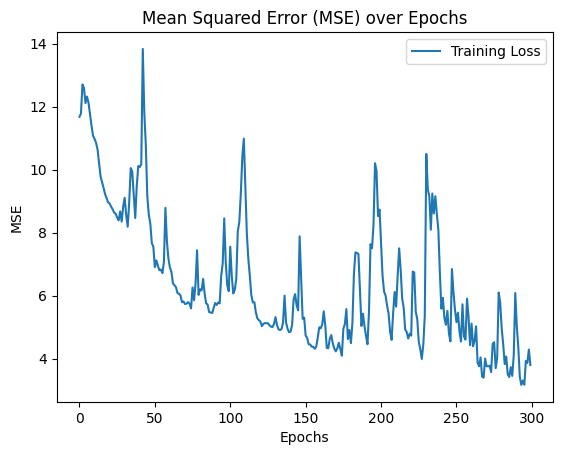

The function training took 36.858917 seconds.


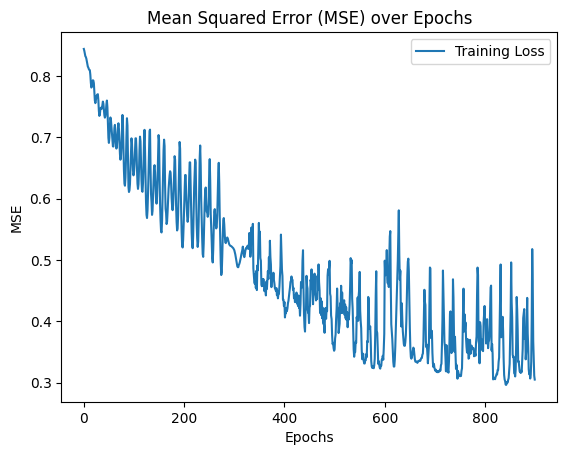

Test MSE: 0.23706741327377198
R^2: 0.9888290775605235


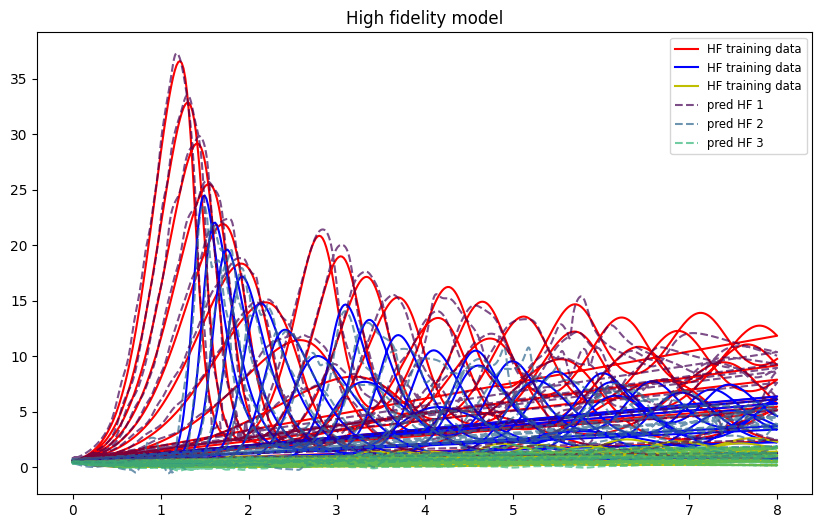

In [12]:
N=[400,1000]
n=[200,250]
names = ['LF', 'HF']

# parameters 
bestLF_params =  {
                  'nodes': 22, 
                  'l2weight': 0.028048305749058373, 
                  'lr': 0.013287693311036268, 
                  'kernel_init': 'glorot_uniform', 
                  'opt': 'Adam'
                  }
best_params= {
              'nodes': 58, 
              'l2weight': 0.0014109037104195455, 
              'lr': 0.07556528693019551, 
              'kernel_init': 'glorot_uniform', 
              'opt': 'Adamax'
              }

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:], y_HF[indices_HF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model_trained = NetworkFactory.build_network(**definition_2steps)

solver_test=System1()
mu_values_test = np.linspace(1, 5, 15)
params_test = [(mu,) for mu in mu_values_test]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=8.0, params=np.array(params), h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test.h5')

datatest=np.array(np.meshgrid(mu_test, t_test)).T.reshape(-1, 2)[:,[1,0]]

y_test_pred=final_model_trained.prediction(datatest)

(mse_MF,R_MF)=final_model_trained.performance(datatest,np.array(y_test).reshape(-1,3))


# Example: Improving the plot by using transparency, a colormap, and reduced marker size
plt.figure(figsize=(10, 6))

# Plotting the training data with smaller markers
plt.plot(x_HF[:, 0], y_HF[:,0], 'r-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,1], 'b-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,2], 'y-', label='HF training data', markersize=2)

# Plotting the prediction data with transparency and a colormap
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '--', color=plt.cm.viridis(i/y_test_pred.shape[1]), alpha=0.7, label=f'pred HF {i+1}')

# Adding legend and title
plt.legend(loc='best', fontsize='small')
plt.title('High fidelity model')

# Show the plot
plt.show()


In [15]:
np.unique(datatest[:,1])

array([1.        , 1.44444444, 1.88888889, 2.33333333, 2.77777778,
       3.22222222, 3.66666667, 4.11111111, 4.55555556, 5.        ])

In [17]:
np.unique(x_HF[:,1])

array([1.        , 1.44444444, 1.88888889, 2.33333333, 2.77777778,
       3.22222222, 3.66666667, 4.11111111, 4.55555556, 5.        ])

In [11]:
y_test.shape

NameError: name 'y_test' is not defined

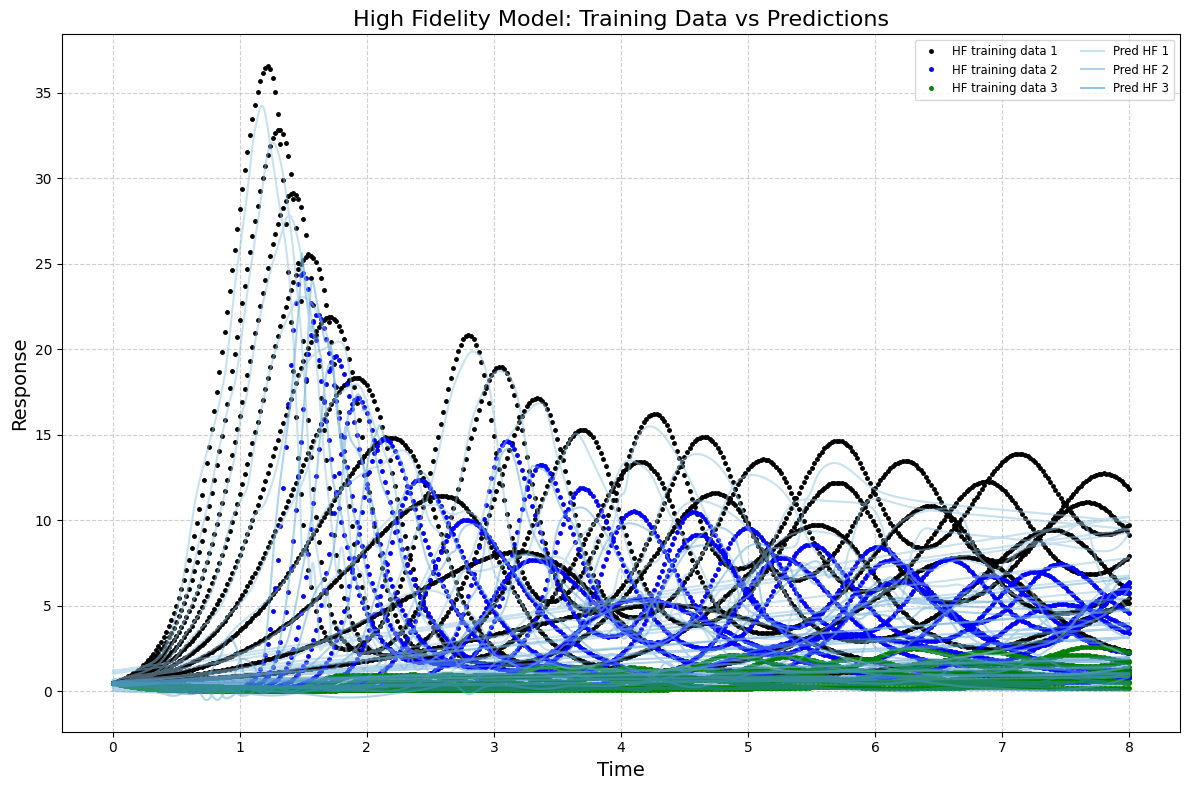

In [10]:
plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(x_HF[:, 0], y_HF[:, 0], 'k.', label='HF training data 1', markersize=5)  # Nero
plt.plot(x_HF[:, 0], y_HF[:, 1], 'b.', label='HF training data 2', markersize=5)  # Blu scuro
plt.plot(x_HF[:, 0], y_HF[:, 2], 'g.', label='HF training data 3', markersize=5)  # Verde scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

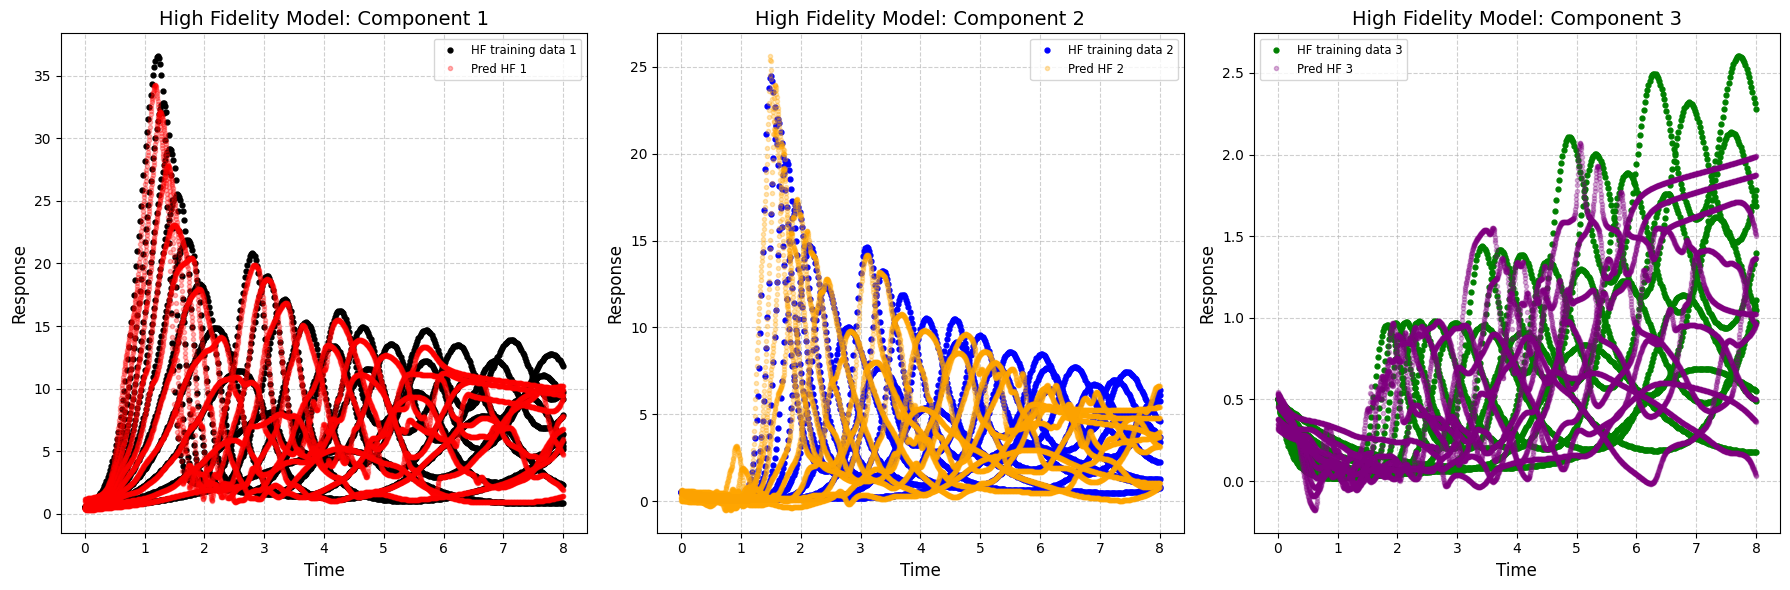

In [11]:
components = ['Component 1', 'Component 2', 'Component 3']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(3):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.3, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

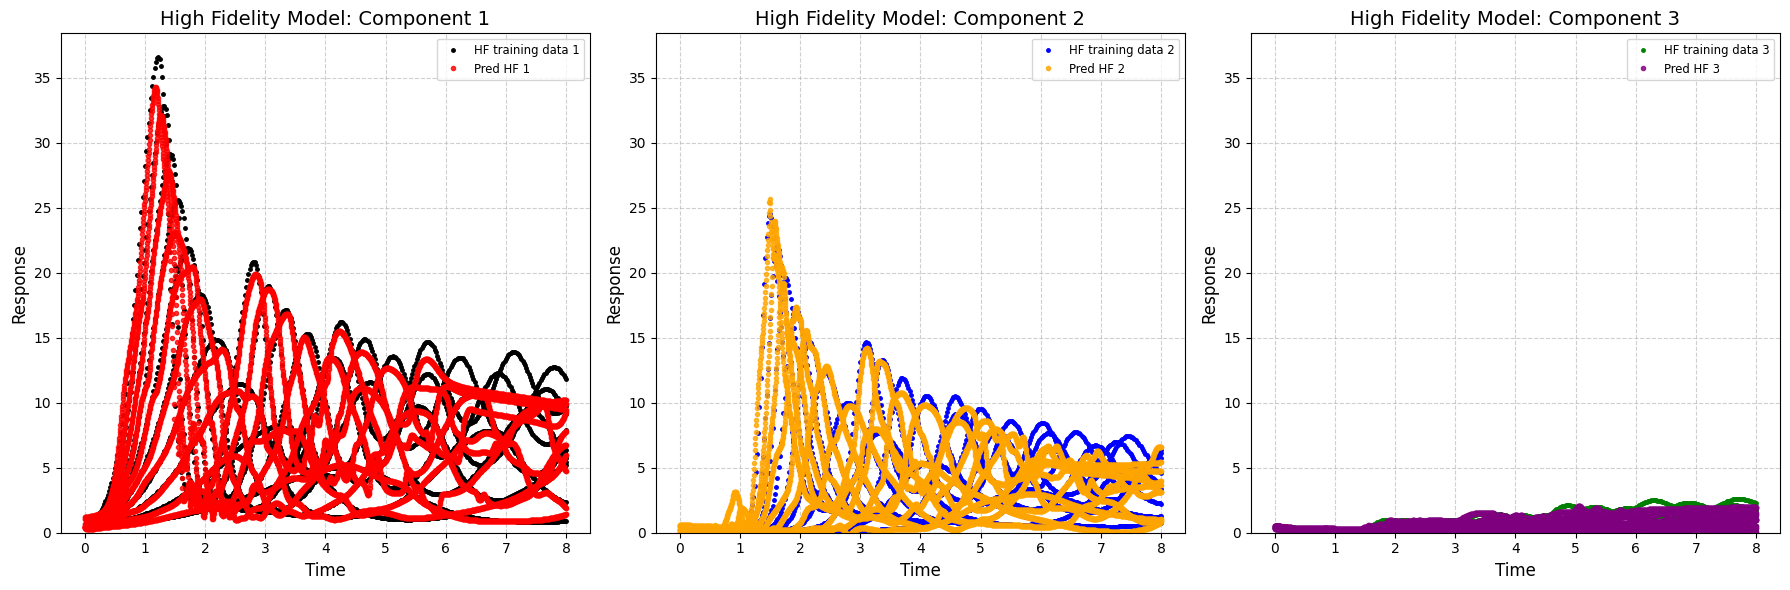

In [13]:
components = ['Component 1', 'Component 2', 'Component 3']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

# Calcola il massimo valore di y considerando tutti i dati (training e predizione)
max_y_value = max(np.max(y_HF), np.max(y_test_pred)) 
y_margin = 0.05 * max_y_value  # Aggiungi un margine del 5% al massimo valore

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(3):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=5)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.8, label=f'Pred HF {i + 1}', linewidth=1.5)
    
    # Imposta il limite dell'asse y
    plt.ylim(0, max_y_value + y_margin)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

Sampling 2 chains in parallel


2024-08-16 16:18:17,958	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [5.056]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.056  0.076   4.901    5.179      0.004    0.003     342.0     323.0   

    r_hat  
x0   1.01  


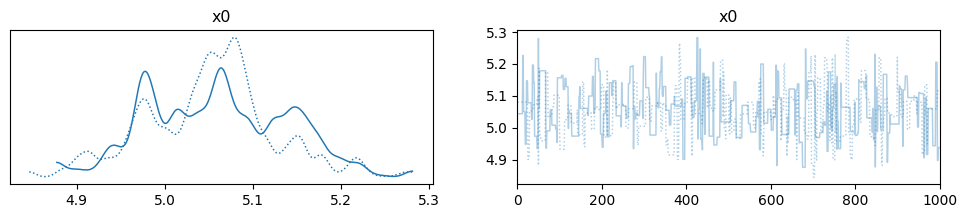

The difference between estimated values [0.056]



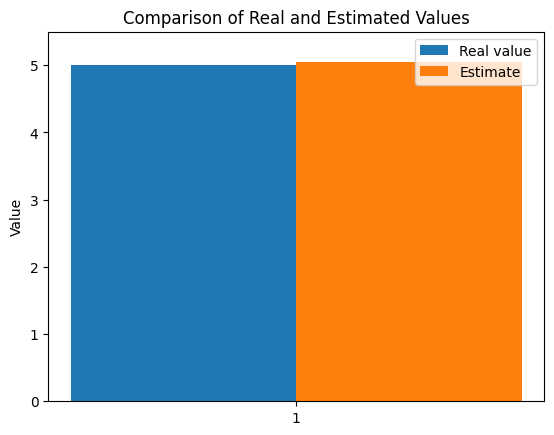

The function param_inverse took 383.364743 seconds.
Sampling 2 chains in parallel


2024-08-16 16:24:25,800	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.053]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.053  0.079   4.928    5.219      0.004    0.003     445.0     378.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


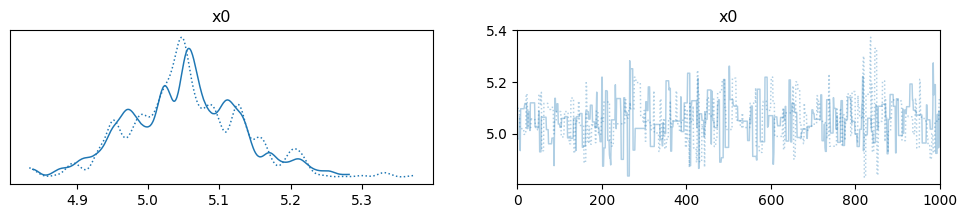

The difference between estimated values [0.053]



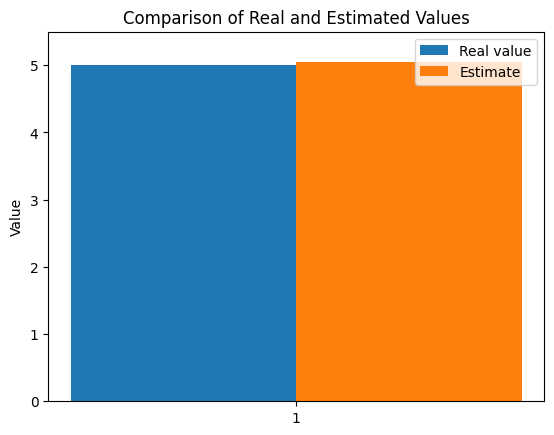

The function param_inverse took 375.776330 seconds.
Sampling 2 chains in parallel


2024-08-16 16:30:55,071	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.056]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.056  0.08   4.927    5.204      0.005    0.004     249.0     339.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


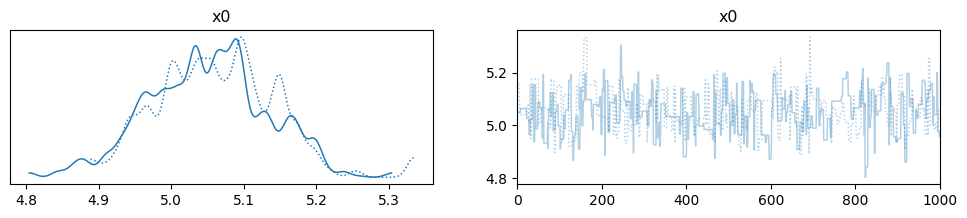

The difference between estimated values [0.056]



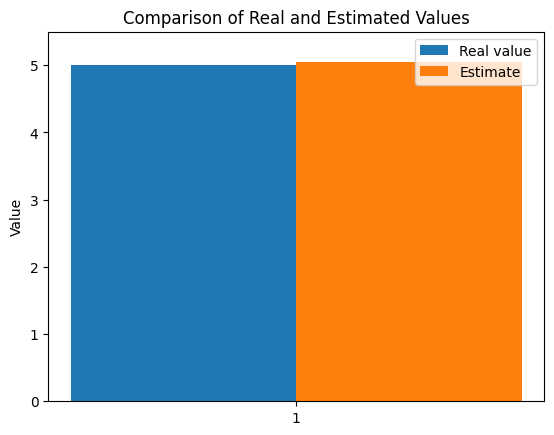

The function param_inverse took 374.539224 seconds.
Sampling 2 chains in parallel


2024-08-16 16:37:10,250	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.047]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.047  0.04   4.974    5.122      0.003    0.002     163.0     216.0   

    r_hat  
x0   1.03  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


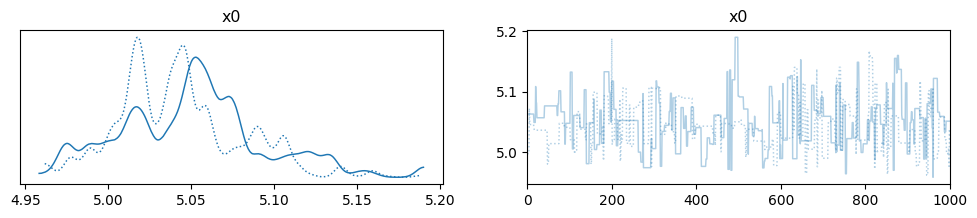

The difference between estimated values [0.047]



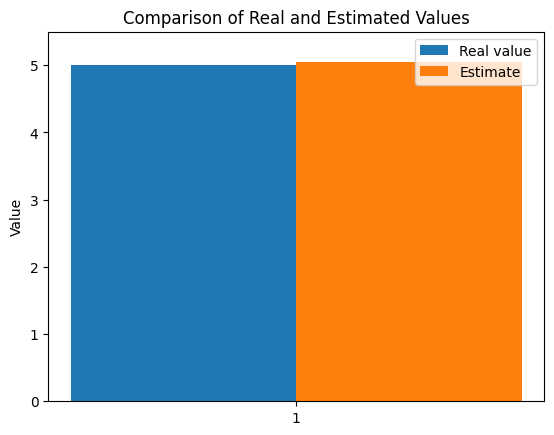

The function param_inverse took 381.299575 seconds.
Sampling 2 chains in parallel


2024-08-16 16:43:18,309	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.055]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.055  0.04   4.989    5.132      0.002    0.002     282.0     273.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


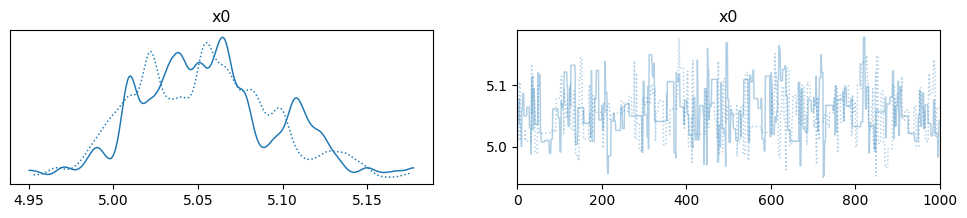

The difference between estimated values [0.055]



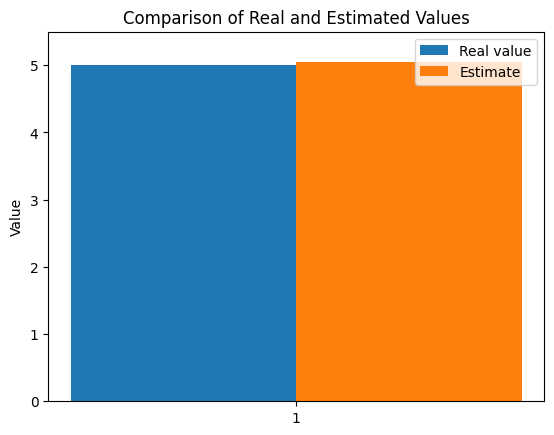

The function param_inverse took 367.622142 seconds.
Sampling 2 chains in parallel


2024-08-16 16:49:30,953	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.053]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.053  0.042   4.979    5.129      0.003    0.002     234.0     244.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


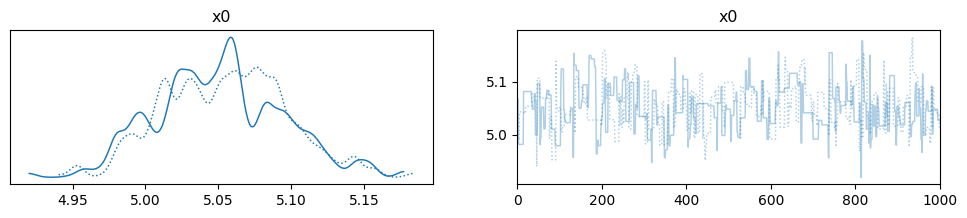

The difference between estimated values [0.053]



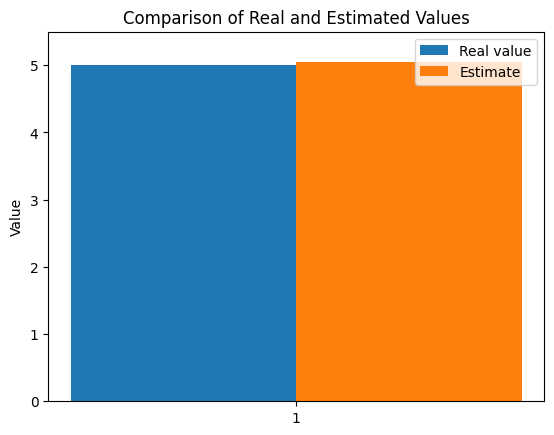

The function param_inverse took 387.969752 seconds.
Sampling 2 chains in parallel


2024-08-16 16:55:50,370	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [5.018]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.018  0.097   4.836    5.201      0.006    0.004     312.0     264.0   

    r_hat  
x0   1.01  


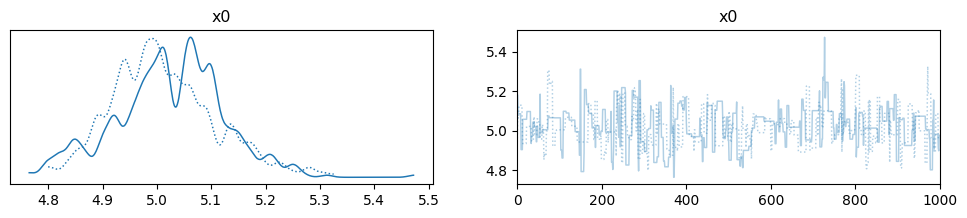

The difference between estimated values [0.018]



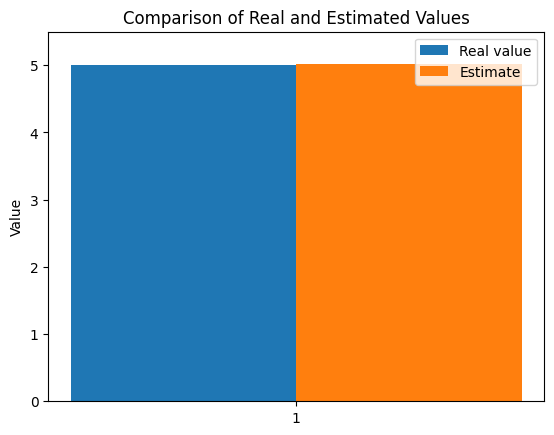

The function param_inverse took 377.628801 seconds.
Sampling 2 chains in parallel


2024-08-16 17:02:18,681	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.008]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.008  0.092    4.85    5.188      0.006    0.004     221.0     296.0   

    r_hat  
x0   1.02  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


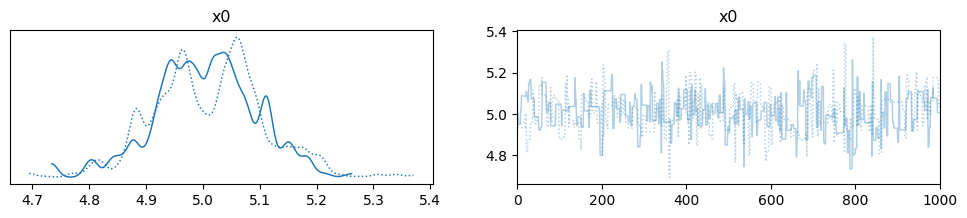

The difference between estimated values [0.008]



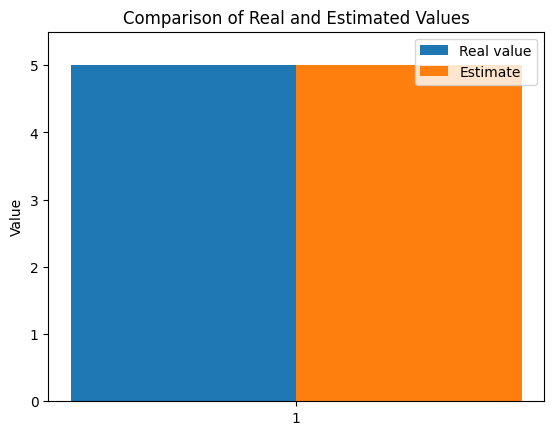

The function param_inverse took 380.430931 seconds.
Sampling 2 chains in parallel


2024-08-16 17:08:30,771	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


ActorDiedError: The actor died because of an error raised in its creation task, [36mray::RemoteChain.__init__()[39m (pid=1515784, ip=127.0.0.1, actor_id=d71ccf8cfeac029996b4c7f601000000, repr=<tinyDA.ray.RemoteChain object at 0x00000291FFA301D0>)
  File "python\ray\_raylet.pyx", line 1901, in ray._raylet.execute_task
  File "python\ray\_raylet.pyx", line 1842, in ray._raylet.execute_task.function_executor
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\_private\function_manager.py", line 691, in actor_method_executor
    return method(__ray_actor, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\util\tracing\tracing_helper.py", line 467, in _resume_span
    return method(self, *_args, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\chain.py", line 70, in __init__
    self.chain.append(self.posterior.create_link(self.initial_parameters)

In [13]:
mean_prior = np.array([2.5])
cov_prior = np.diag([1.])

sigma_noise = [0.25,0.5]
n_data = [30,20,10]
parameters = np.array([5.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 2000
burnin = 1000
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model_trained,algo)


In [ ]:
cov_prior = np.diag([1.,1.,1.])


In [12]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = y_HF
sd_noise = [0.1,0.05]
N = 300
burn_in = 200
number_chains = 2
algo = "MH"
x_real = np.array([5.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(x_HF, x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(x_HF,y_HF,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=False
) 

ValueError: operands could not be broadcast together with shapes (50,3) (150,) 

In [ ]:
x_HF.shape

(5010, 2)

In [ ]:
mean=np.mean(x_HF)

In [ ]:
mean

4.0

In [ ]:
# Name of the folder
folder_name = "2_step_models_mu"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
            
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

data_HF_test=np.empty((0,data_HF.shape[1]))
data_HF_train=np.empty((0,data_HF.shape[1]))
data_LF_test=np.empty((0,data_LF.shape[1]))
data_LF_train=np.empty((0,data_LF.shape[1]))

In [ ]:
nlf=200
nhf=150
batch_size=[nlf,nhf]

# number of epochs 
Nepo = [1000,10000]

indexes_LF = np.where(np.diff(data_LF[:,-1]) != 0)[0] + 1
indexes_LF = np.insert(indexes_LF, 0, 0)
indexes_LF = np.append(indexes_LF, len(data_LF))


indexes_HF = np.where(np.diff(data_HF[:,-1]) != 0)[0] + 1
indexes_HF = np.insert(indexes_HF, 0, 0)
indexes_HF = np.append(indexes_HF, len(data_HF))


r2_HF_df = pandas.DataFrame(columns=['mu','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['mu','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['mu','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['mu','MSE'])  # dataframe which stores LF MSE